# Two motor items as a suggestibility screener

**Arm rigidity + arm immobilisation as a proxy for PCS / SWASH / HGSHS:A totals**

This notebook is the complete analysis. All computations are inline; the only
external dependency is `lib_data.py`, which handles canonical scoring and data
loading.

**What is tested:** whether the sum of two motor-challenge items correlates with
the full-scale total closely enough to serve as a first-pass screener in unselected
student samples, and whether the pair retains the full scale's signal against
external criteria that share no items with the scale.

**Scope:** all administrations are embedded — participants completed all ten items.
Results describe an embedded proxy, not a standalone instrument.


## Setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import combinations
from scipy.stats import pearsonr, spearmanr, norm, zscore as stats_zscore
from sklearn.metrics import cohen_kappa_score, confusion_matrix, roc_curve, auc
from IPython.display import display

from lib_data import (
    load_all, load_retest, load_external_validity,
    MOTOR_COLS, ITEMS_DF1, ITEMS_DF2, ITEMS_DF3, ITEMS_DF5,
    LABELS_PCS, TYPES_PCS, COLOUR_MAP,
    bootstrap_ci, spearman_brown, N_BOOT,
)

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
os.makedirs('tables',  exist_ok=True)

dfs = load_all()
rt_pcs, rt_swash = load_retest()
ext = load_external_validity()

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 20)

print('Datasets loaded:')
for k, df in dfs.items():
    print(f'  {k}: n={len(df)}')


Datasets loaded:
  df1_pcs: n=244
  df1_swash: n=240
  df2: n=508
  df3: n=418
  df4: n=584
  df5: n=452


---
## 1. Scales and datasets

PCS and SWASH use ten matched suggestion items rated 0–5 for subjective intensity.
HGSHS:A uses a related item set but measures involuntariness (0–5 Bowers scale) and was
administered as a group scale. The three scales are analysed separately throughout;
PCS and HGSHS:A intensity ratings are never pooled.

Motor-pair items by dataset:
- **df1 PCS / SWASH:** ArmRigiditySubjectiveRating + ArmImmobilisationSubjectiveRating
- **df2, df5 PCS:** StiffArm + HandAndArmHeavy
- **df3 SWASH:** Q5RIGIDITYSUBJ + Q6IMMOBILESUBJ
- **df4 HGSHS:A (involuntariness):** INV.6 + INV.4

Exclusion flags applied: df1 `exclude==1` (n=6), df4 `Missing==1` (n=18),
df5 `Incomplete_exclude==1` (n=62).


In [2]:
summary_configs = [
    ('df1_pcs',   'df1 PCS',        'PCS',     'intensity',       'Subjective_scale_score_first_test'),
    ('df1_swash', 'df1 SWASH',      'SWASH',   'intensity',       'Subjective_scale_score_first_test'),
    ('df2',       'df2 PCS-VVIQ',   'PCS',     'intensity',       'SubjectiveTotal'),
    ('df3',       'df3 SWASH',      'SWASH',   'intensity',       'Subjectivescore'),
    ('df4',       'df4 HGSHS inv.', 'HGSHS:A', 'involuntariness', 'INV_total'),
    ('df5',       'df5 vEAR PCS',   'PCS',     'intensity',       'PCscore'),
]
rows = []
for key, label, scale, dim, tc in summary_configs:
    df = dfs[key]
    rows.append({
        'dataset':    label,
        'scale':      scale,
        'dimension':  dim,
        'n':          len(df),
        'total_mean': round(df[tc].mean(), 3),
        'total_sd':   round(df[tc].std(ddof=1), 3),
    })
display(pd.DataFrame(rows))


,dataset,scale,dimension,n,total_mean,total_sd
0,df1 PCS,PCS,intensity,244,1.933,0.670
1,df1 SWASH,SWASH,intensity,240,1.527,0.795
2,df2 PCS-VVIQ,PCS,intensity,508,1.842,0.671
3,df3 SWASH,SWASH,intensity,418,1.691,0.804
4,df4 HGSHS inv.,HGSHS:A,involuntariness,584,2.378,0.975
5,df5 vEAR PCS,PCS,intensity,452,1.847,0.718


---
## 2. Convergence: motor pair vs full score

Two correlation metrics per dataset:

**r_full (part-whole):** motor pair sum vs full-scale total. The motor items are inside
the total, which inflates the correlation. This is the standard design in published
short-form validation work (same as HGSHS-5:G r=0.83).

**r_rest (part-rest):** motor pair sum vs the mean of the remaining 8 items.
Overlap-free; conservative complement.

**Spearman-Brown reliability:** `2r/(1+r)` where r is the rigidity–immobilisation
inter-item correlation (Eisinga et al. 2013 — the correct 2-item reliability coefficient).

All CIs are 95% bootstrap (n_boot=2000, seed=20260603).


In [3]:
def conv_row(df, mc_key, total_col, rest_col, label, dim, n_boot=N_BOOT):
    mc    = MOTOR_COLS[mc_key]
    motor = df[mc].sum(axis=1).dropna()
    total = df.loc[motor.index, total_col].dropna()
    rest  = df.loc[motor.index, rest_col].dropna()
    ct    = motor.index.intersection(total.index)
    cr    = motor.index.intersection(rest.index)
    m, t  = motor[ct].values.astype(float), total[ct].values.astype(float)
    mr, r = motor[cr].values.astype(float), rest[cr].values.astype(float)
    rf, pf = pearsonr(m, t)
    rr, pr = pearsonr(mr, r)
    lo,  hi  = bootstrap_ci(m,  t, 'pearson', n_boot=n_boot)
    rlo, rhi = bootstrap_ci(mr, r, 'pearson', n_boot=n_boot)
    x1 = df[mc[0]].dropna()
    x2 = df[mc[1]].dropna()
    idx = x1.index.intersection(x2.index)
    sb_r, _ = pearsonr(x1[idx].values, x2[idx].values)
    return {
        'dataset':       label,
        'dim':           dim,
        'n':             len(m),
        'r_full':        round(rf,    3),
        'p_full':        float(pf),
        'R2':            round(rf**2, 3),
        'r_full_ci_lo':  round(lo,   3),
        'r_full_ci_hi':  round(hi,   3),
        'r_full_95CI':   f'[{lo:.3f}, {hi:.3f}]',
        'r_rest':        round(rr,    3),
        'p_rest':        float(pr),
        'r_rest_ci_lo':  round(rlo,   3),
        'r_rest_ci_hi':  round(rhi,   3),
        'r_rest_95CI':   f'[{rlo:.3f}, {rhi:.3f}]',
        'SB_reli':       round(spearman_brown(sb_r), 3),
    }

conv_configs = [
    ('df1_pcs',   'df1',     'Subjective_scale_score_first_test', 'rest_score',     'df1 PCS',        'intensity'),
    ('df2',       'df2',     'SubjectiveTotal',                   'rest_score',     'df2 PCS-VVIQ',   'intensity'),
    ('df5',       'df5',     'PCscore',                           'rest_score',     'df5 vEAR PCS',   'intensity'),
    ('df1_swash', 'df1',     'Subjective_scale_score_first_test', 'rest_score',     'df1 SWASH',      'intensity'),
    ('df3',       'df3',     'Subjectivescore',                   'rest_score',     'df3 SWASH',      'intensity'),
    ('df4',       'df4_inv', 'INV_total',                         'rest_score_inv', 'df4 HGSHS inv.', 'involuntariness'),
    ('df4',       'df4_obj', 'OBJ_total',                         'rest_score_obj', 'df4 HGSHS obj.', 'objective'),
]
conv_df = pd.DataFrame([conv_row(dfs[k], mk, tc, rc, lbl, dim)
                        for k, mk, tc, rc, lbl, dim in conv_configs])
display(conv_df[['dataset', 'n', 'r_full', 'R2', 'r_full_95CI', 'r_rest', 'r_rest_95CI', 'SB_reli']])

,dataset,n,r_full,R2,r_full_95CI,r_rest,r_rest_95CI,SB_reli
0,df1 PCS,244,0.783,0.613,"[0.729, 0.829]",0.565,"[0.472, 0.646]",0.612
1,df2 PCS-VVIQ,508,0.778,0.605,"[0.739, 0.811]",0.549,"[0.482, 0.610]",0.626
2,df5 vEAR PCS,452,0.785,0.617,"[0.749, 0.820]",0.579,"[0.514, 0.642]",0.619
3,df1 SWASH,240,0.849,0.720,"[0.815, 0.880]",0.694,"[0.627, 0.753]",0.791
4,df3 SWASH,418,0.807,0.652,"[0.774, 0.838]",0.630,"[0.571, 0.687]",0.746
5,df4 HGSHS inv.,584,0.799,0.638,"[0.766, 0.827]",0.659,"[0.606, 0.705]",0.695
6,df4 HGSHS obj.,584,0.682,0.464,"[0.639, 0.721]",0.449,"[0.385, 0.511]",0.424


In [4]:
def fishers_z_test(r1, n1, r2, n2):
    """Fisher's r-to-z comparison of two independent correlations."""
    z1 = np.arctanh(r1); z2 = np.arctanh(r2)
    se = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z  = (z1 - z2) / se
    p  = 2 * (1 - norm.cdf(abs(z)))
    return round(float(z), 3), round(float(p), 4)

def fmt_p(p):
    return '< .001' if p < .001 else f'= {p:.3f}'

# df1 comparison: randomly assigned conditions — cleanest test
pcs_r   = conv_df[conv_df['dataset'] == 'df1 PCS']
swash_r = conv_df[conv_df['dataset'] == 'df1 SWASH']

print('Fisher r-to-z: df1 PCS vs df1 SWASH (randomly assigned conditions)')
for metric, r_col in [('r_full', 'r_full'), ('r_rest', 'r_rest')]:
    pr = pcs_r.iloc[0];  sr = swash_r.iloc[0]
    z, p = fishers_z_test(pr[r_col], pr['n'], sr[r_col], sr['n'])
    print(f'  {metric}: PCS {pr[r_col]:.3f} vs SWASH {sr[r_col]:.3f}  z={z:.3f}, p {fmt_p(p)}')

# Cross-dataset pairs (not randomly assigned; between-cohort variability dominates)
print()
print('Fisher r-to-z: cross-dataset PCS vs SWASH (note: different cohorts)')
cross = [
    ('df2 PCS-VVIQ', 'df3 SWASH'),
    ('df5 vEAR PCS', 'df3 SWASH'),
]
for pcs_lbl, swash_lbl in cross:
    pr = conv_df[conv_df['dataset'] == pcs_lbl].iloc[0]
    sr = conv_df[conv_df['dataset'] == swash_lbl].iloc[0]
    z, p = fishers_z_test(pr['r_full'], pr['n'], sr['r_full'], sr['n'])
    print(f'  r_full: {pcs_lbl} {pr["r_full"]:.3f} vs {swash_lbl} {sr["r_full"]:.3f}  z={z:.3f}, p {fmt_p(p)}')


Fisher r-to-z: df1 PCS vs df1 SWASH (randomly assigned conditions)
  r_full: PCS 0.783 vs SWASH 0.849  z=-2.181, p = 0.029
  r_rest: PCS 0.565 vs SWASH 0.694  z=-2.356, p = 0.018

Fisher r-to-z: cross-dataset PCS vs SWASH (note: different cohorts)
  r_full: df2 PCS-VVIQ 0.778 vs df3 SWASH 0.807  z=-1.179, p = 0.239
  r_full: df5 vEAR PCS 0.785 vs df3 SWASH 0.807  z=-0.883, p = 0.378


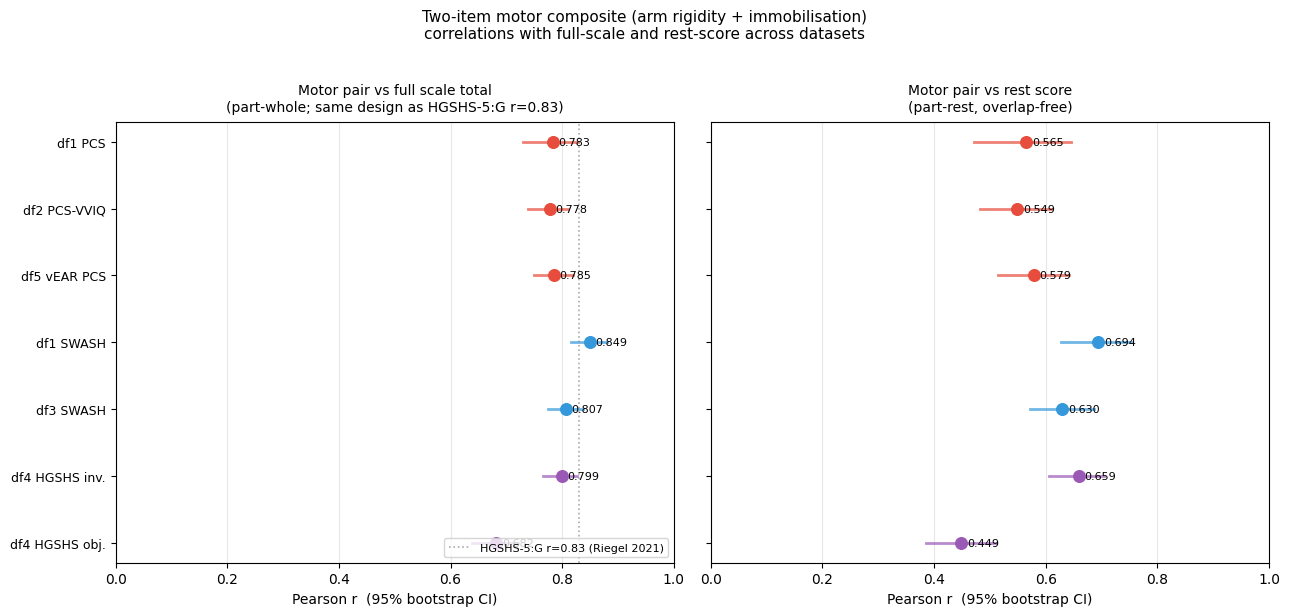

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

labels  = conv_df['dataset'].tolist()
y_pos   = list(range(len(labels), 0, -1))
colours = ['#e74c3c' if 'PCS' in l else '#3498db' if 'SWASH' in l else '#9b59b6'
           for l in labels]

for ax, r_col, lo_col, hi_col, title, bench_r in [
    (axes[0], 'r_full', 'r_full_ci_lo', 'r_full_ci_hi',
     'Motor pair vs full scale total\n(part-whole; same design as HGSHS-5:G r=0.83)', 0.83),
    (axes[1], 'r_rest', 'r_rest_ci_lo', 'r_rest_ci_hi',
     'Motor pair vs rest score\n(part-rest, overlap-free)', None),
]:
    rs = conv_df[r_col].values
    lo = conv_df[lo_col].values
    hi = conv_df[hi_col].values

    for y, r, l, h, c in zip(y_pos, rs, lo, hi, colours):
        ax.plot([l, h], [y, y], lw=2, color=c, alpha=0.7)
        ax.scatter([r], [y], color=c, s=70, zorder=5)
    ax.axvline(0, color='#555', lw=0.7, ls='--')
    if bench_r:
        ax.axvline(bench_r, color='#888', lw=1.2, ls=':', alpha=0.7,
                   label=f'HGSHS-5:G r={bench_r} (Riegel 2021)')
        ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(0, 1.0)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Pearson r  (95% bootstrap CI)', fontsize=10)
    ax.set_title(title, fontsize=10, pad=8)
    ax.grid(axis='x', alpha=0.3)
    for y, r in zip(y_pos, rs):
        ax.text(r + 0.01, y, f'{r:.3f}', va='center', fontsize=8)

fig.suptitle('Two-item motor composite (arm rigidity + immobilisation)\n'
             'correlations with full-scale and rest-score across datasets',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('figures/fig1_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()


**Figure 1.** Part-whole (left) and part-rest (right) correlations with 95% bootstrap CIs.
The dotted line marks r=0.83 from a five-item HGSHS:A short form in the published literature.

SWASH (hypnotic context) shows higher coupling than PCS (non-hypnotic) at every comparison —
part-rest r 0.63–0.69 vs 0.55–0.58, weighted kappa 0.65–0.66 vs 0.50–0.55.
The motor-item structure replicates across contexts, but the magnitude does not.


---
## 3. Floor effect: why the proxy correlation is high

Music hallucination and negative visual hallucination are near floor in all datasets
(80–93% at zero). The motor items sit near mid-scale (mean 2.5–3.2/5), where variance
is highest and discrimination is greatest.

When near-floor items dominate a scale, the total is largely determined by the few items
that actually vary. The motor pair's high part-whole correlation is partly structural:
removing near-floor items from the total costs almost no discriminating information.
This is the mechanism, not an argument against the screening claim.


In [6]:
def item_stats(df, items, labels, types, dataset_label, scale_max=5.0):
    rows = []
    for i, col in enumerate(items):
        x = df[col].dropna().values
        rows.append({
            'dataset':     dataset_label,
            'item_num':    i + 1,
            'item_label':  labels[i],
            'item_type':   types[i],
            'mean':        round(float(np.mean(x)), 3),
            'sd':          round(float(np.std(x, ddof=1)), 3),
            'pct_floor':   round(100 * float(np.mean(x == 0)), 1),
            'pct_ceiling': round(100 * float(np.mean(x == scale_max)), 1),
        })
    return rows

desc_configs = [
    ('df1_pcs',   ITEMS_DF1, 'df1 PCS (cond=0)'),
    ('df1_swash', ITEMS_DF1, 'df1 SWASH (cond=1)'),
    ('df2',       ITEMS_DF2, 'df2 PCS-VVIQ'),
    ('df3',       ITEMS_DF3, 'df3 SWASH'),
    ('df5',       ITEMS_DF5, 'df5 vEAR PCS'),
]
all_desc = []
for key, items, label in desc_configs:
    all_desc.extend(item_stats(dfs[key], items, LABELS_PCS, TYPES_PCS, label))
desc = pd.DataFrame(all_desc)

pcs_items = desc[desc['dataset'] == 'df1 PCS (cond=0)'].sort_values('item_num')
display(pcs_items[['item_label', 'item_type', 'mean', 'sd', 'pct_floor', 'pct_ceiling']]
        .rename(columns={'item_label': 'Item', 'item_type': 'Type',
                         'mean': 'Mean', 'sd': 'SD',
                         'pct_floor': '% floor', 'pct_ceiling': '% ceiling'})
        .reset_index(drop=True))

# Floor item summary across datasets
print('\nFloor item (music + neg.visual) means across intensity datasets:')
floor_types = desc[desc['item_type'].isin(['perceptual'])][
    ['dataset', 'item_label', 'mean', 'pct_floor']
].sort_values(['dataset', 'item_label'])
print(floor_types.to_string(index=False))


,Item,Type,Mean,SD,% floor,% ceiling
0,Hand lowering,motor,3.643,1.190,2.000,26.200
1,Moving hands together,motor,3.094,1.291,4.500,11.100
2,Mosquito hallucination,perceptual,1.656,1.478,31.100,4.100
3,Taste hallucination,perceptual,1.750,1.348,16.400,1.200
4,Arm rigidity*,motor,3.201,1.419,5.300,17.200
5,Arm immobilisation*,motor,2.676,1.402,9.000,7.400
6,Music hallucination,perceptual,0.266,0.845,86.500,1.200
7,Neg. visual hallucination,perceptual,0.373,1.229,90.200,5.700
8,Amnesia,cognitive,1.648,1.396,27.500,1.600
9,Post-hypnotic suggestion,cognitive,1.025,1.470,62.700,1.200



Floor item (music + neg.visual) means across intensity datasets:
           dataset                item_label  mean  pct_floor
  df1 PCS (cond=0)    Mosquito hallucination 1.656     31.100
  df1 PCS (cond=0)       Music hallucination 0.266     86.500
  df1 PCS (cond=0) Neg. visual hallucination 0.373     90.200
  df1 PCS (cond=0)       Taste hallucination 1.750     16.400
df1 SWASH (cond=1)    Mosquito hallucination 0.975     53.800
df1 SWASH (cond=1)       Music hallucination 0.138     90.800
df1 SWASH (cond=1) Neg. visual hallucination 0.237     92.100
df1 SWASH (cond=1)       Taste hallucination 1.117     36.200
      df2 PCS-VVIQ    Mosquito hallucination 1.374     38.600
      df2 PCS-VVIQ       Music hallucination 0.352     81.700
      df2 PCS-VVIQ Neg. visual hallucination 0.199     92.700
      df2 PCS-VVIQ       Taste hallucination 1.759     21.700
         df3 SWASH    Mosquito hallucination 0.957     55.000
         df3 SWASH       Music hallucination 0.230     86.400
    

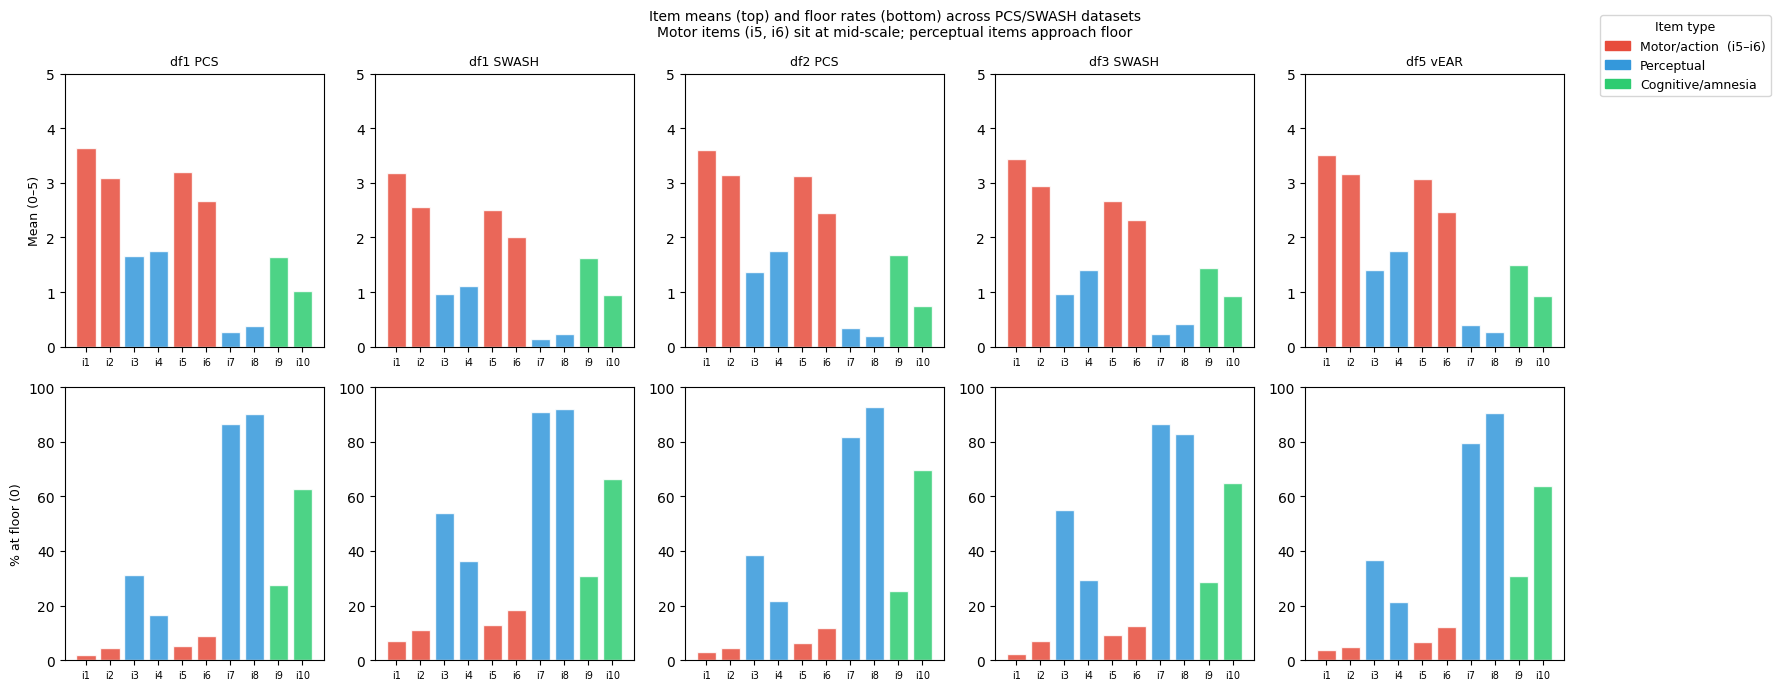

In [7]:
from matplotlib.patches import Patch

datasets_to_plot = [
    ('df1 PCS (cond=0)',  'df1 PCS'),
    ('df1 SWASH (cond=1)', 'df1 SWASH'),
    ('df2 PCS-VVIQ',      'df2 PCS'),
    ('df3 SWASH',         'df3 SWASH'),
    ('df5 vEAR PCS',      'df5 vEAR'),
]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for col, (full_label, short_label) in enumerate(datasets_to_plot):
    sub = desc[desc['dataset'] == full_label].copy().sort_values('item_num').reset_index(drop=True)
    bar_colours = [COLOUR_MAP.get(t, '#888') for t in sub['item_type']]
    x = range(len(sub))

    axes[0, col].bar(x, sub['mean'], color=bar_colours, alpha=0.85, edgecolor='white')
    axes[0, col].set_title(short_label, fontsize=9)
    axes[0, col].set_xticks(x)
    axes[0, col].set_xticklabels([f'i{i+1}' for i in range(len(sub))], fontsize=7)
    axes[0, col].set_ylim(0, 5)
    if col == 0:
        axes[0, col].set_ylabel('Mean (0–5)', fontsize=9)

    axes[1, col].bar(x, sub['pct_floor'], color=bar_colours, alpha=0.85, edgecolor='white')
    axes[1, col].set_xticks(x)
    axes[1, col].set_xticklabels([f'i{i+1}' for i in range(len(sub))], fontsize=7)
    axes[1, col].set_ylim(0, 100)
    if col == 0:
        axes[1, col].set_ylabel('% at floor (0)', fontsize=9)

legend_els = [
    Patch(color=COLOUR_MAP['motor'],      label='Motor/action  (i5–i6)'),
    Patch(color=COLOUR_MAP['perceptual'], label='Perceptual'),
    Patch(color=COLOUR_MAP['cognitive'],  label='Cognitive/amnesia'),
]
fig.legend(handles=legend_els, loc='upper right', fontsize=9,
           title='Item type', title_fontsize=9, bbox_to_anchor=(0.99, 0.98))
fig.suptitle('Item means (top) and floor rates (bottom) across PCS/SWASH datasets\n'
             'Motor items (i5, i6) sit at mid-scale; perceptual items approach floor',
             fontsize=10)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig('figures/fig3_item_floor.png', dpi=300, bbox_inches='tight')
plt.show()


**Figure 2.** Item means (top row) and floor rates (bottom row) across all five intensity datasets.
Motor items (i5 = arm rigidity, i6 = arm immobilisation) are red; perceptual items are blue;
cognitive/amnesia are green.


---
## 4. External validity

The part-whole correlation involves shared items on both sides. External criteria —
measures with no item overlap with the PCS — provide a cleaner test of whether the
motor pair captures the underlying construct.

Signal-retention percentages are correlation ratios (motor r / full-scale r).
In variance terms (R² ratio), the figures are lower: vEAR ~64% vs the 80% correlation ratio.

**DES caveat:** full PCS r=0.107, motor pair r=0.100. Both are near-zero.
The 93% ratio reflects two small effects agreeing, not meaningful retained signal.
The substantive external evidence is vEAR (motor r≈0.30 vs full r≈0.37) and
the anomalous-experience criteria.


In [8]:
def ext_row(x, y, predictor_label, criterion_label, dataset, n_boot=N_BOOT):
    xa = np.asarray(x, dtype=float)
    ya = np.asarray(y, dtype=float)
    mask = np.isfinite(xa) & np.isfinite(ya)
    xa, ya = xa[mask], ya[mask]
    if len(xa) < 20:
        return None
    rp, p = pearsonr(xa, ya)
    ci_lo, ci_hi = bootstrap_ci(xa, ya, 'pearson', n_boot=n_boot)
    return {
        'dataset':   dataset,
        'predictor': predictor_label,
        'criterion': criterion_label,
        'n':         len(xa),
        'pearson_r': round(rp,    3),
        'p_value':   float(p),
        'r2':        round(rp**2, 3),
        'ci_lo':     round(ci_lo, 3),
        'ci_hi':     round(ci_hi, 3),
    }

ext_rows = []

# df5: vEAR
df5 = dfs['df5']
for crit_col, crit_label in [('vEARscoreFromVideoRatings', 'vEAR_score'),
                              ('AveVEAR', 'vEAR_avg_self_report')]:
    if crit_col in df5.columns:
        for pc, pl in [('motor_pair_sum','motor_pair'),('PCscore','full_scale'),('rest_score','rest_score')]:
            r = ext_row(df5[pc], df5[crit_col], pl, crit_label, 'df5 vEAR PCS')
            if r: ext_rows.append(r)

# Anomalous
anom = ext['anomalous']
for col, lbl in [('comb exp','anomalous_combined'),('out_of_body_experience','OBE_experience'),
                 ('past_life_experience','past_life_experience'),
                 ('spirit_world_experience','spirit_world_experience')]:
    if col in anom.columns:
        for pc, pl in [('motor_pair_sum','motor_pair'),('PCSscore','full_scale'),('rest_score','rest_score')]:
            r = ext_row(anom[pc], anom[col], pl, lbl, 'anomalous_PCS')
            if r: ext_rows.append(r)

# Flow
flow = ext['flow']
for col, lbl in [('Flow_combined','flow_combined'),('Flow_vacuuming','flow_vacuuming'),
                 ('Flow_essay_writing','flow_essay_writing'),('Flow_exercise','flow_exercise')]:
    if col in flow.columns:
        for pc, pl in [('motor_pair_sum','motor_pair'),('PCSscore','full_scale'),('rest_score','rest_score')]:
            r = ext_row(flow[pc], flow[col], pl, lbl, 'flow_PCS')
            if r: ext_rows.append(r)

# DES
des = ext['des']
for pc, pl in [('motor_pair_sum','motor_pair'),('PCSscore','full_scale'),('rest_score','rest_score')]:
    r = ext_row(des[pc], des['DES_score'], pl, 'DES_dissociation', 'DES_PCS')
    if r: ext_rows.append(r)

ext_df = pd.DataFrame(ext_rows)

# Comparison table: motor vs full for main criteria
criteria_main = ['vEAR_score', 'anomalous_combined', 'past_life_experience',
                 'DES_dissociation', 'flow_combined']
me = ext_df[ext_df['predictor'] == 'motor_pair'].set_index('criterion')
fe = ext_df[ext_df['predictor'] == 'full_scale'].set_index('criterion')
cmp_rows = []
for crit in criteria_main:
    if crit in me.index and crit in fe.index:
        m, f = me.loc[crit], fe.loc[crit]
        pct = int(round(100 * m['pearson_r'] / f['pearson_r'])) if f['pearson_r'] > 0.01 else '—'
        cmp_rows.append({
            'criterion':   crit,
            'N':           m['n'],
            'motor r':     m['pearson_r'],
            'motor CI':    f"[{m['ci_lo']:.3f}, {m['ci_hi']:.3f}]",
            'full r':      f['pearson_r'],
            'full CI':     f"[{f['ci_lo']:.3f}, {f['ci_hi']:.3f}]",
            '% r retained': pct,
        })
display(pd.DataFrame(cmp_rows))


,criterion,N,motor r,motor CI,full r,full CI,% r retained
0,vEAR_score,452,0.297,"[0.215, 0.369]",0.372,"[0.293, 0.445]",80
1,anomalous_combined,497,0.155,"[0.055, 0.245]",0.202,"[0.098, 0.296]",77
2,past_life_experience,497,0.158,"[0.064, 0.249]",0.221,"[0.118, 0.317]",71
3,DES_dissociation,559,0.100,"[0.022, 0.175]",0.107,"[0.029, 0.185]",93
4,flow_combined,432,0.109,"[0.004, 0.210]",0.139,"[0.039, 0.237]",78


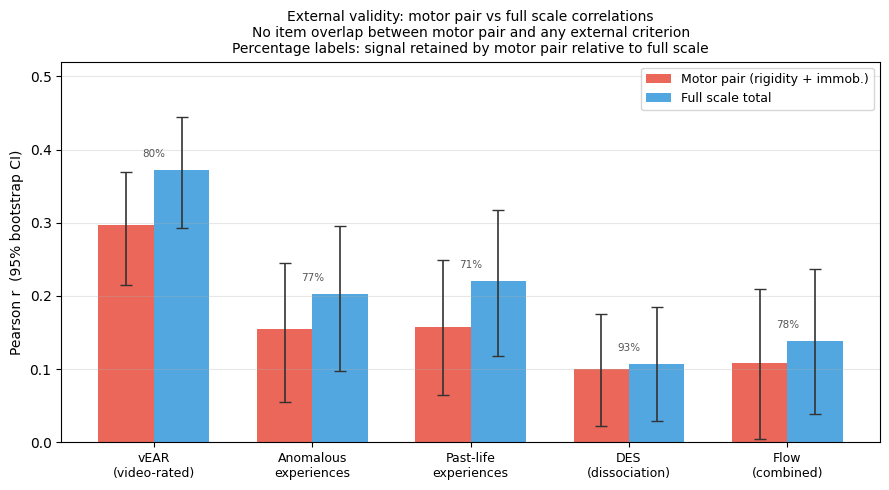

In [9]:
criteria_order = [
    ('vEAR_score',           'vEAR\n(video-rated)'),
    ('anomalous_combined',   'Anomalous\nexperiences'),
    ('past_life_experience', 'Past-life\nexperiences'),
    ('DES_dissociation',     'DES\n(dissociation)'),
    ('flow_combined',        'Flow\n(combined)'),
]

motor_rs, full_rs = [], []
motor_lo, motor_hi, full_lo, full_hi = [], [], [], []
xlabels = []

for crit_col, crit_label in criteria_order:
    ms = ext_df[(ext_df['criterion'] == crit_col) & (ext_df['predictor'] == 'motor_pair')]
    fs = ext_df[(ext_df['criterion'] == crit_col) & (ext_df['predictor'] == 'full_scale')]
    if ms.empty or fs.empty:
        continue
    m, f = ms.iloc[0], fs.iloc[0]
    motor_rs.append(m['pearson_r']); full_rs.append(f['pearson_r'])
    motor_lo.append(m['pearson_r'] - m['ci_lo']); motor_hi.append(m['ci_hi'] - m['pearson_r'])
    full_lo.append(f['pearson_r']  - f['ci_lo']); full_hi.append(f['ci_hi']  - f['pearson_r'])
    xlabels.append(crit_label)

n = len(xlabels); x = np.arange(n); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, motor_rs, w, label='Motor pair (rigidity + immob.)', color='#e74c3c', alpha=0.85)
ax.bar(x + w/2, full_rs,  w, label='Full scale total',               color='#3498db', alpha=0.85)
ax.errorbar(x - w/2, motor_rs, yerr=[motor_lo, motor_hi], fmt='none', color='#333', capsize=4, lw=1.2)
ax.errorbar(x + w/2, full_rs,  yerr=[full_lo,  full_hi],  fmt='none', color='#333', capsize=4, lw=1.2)
for xi, mr, fr in zip(x, motor_rs, full_rs):
    if fr > 0.01:
        ax.text(xi, max(mr, fr) + 0.015, f'{int(round(100*mr/fr))}%',
                ha='center', va='bottom', fontsize=7.5, color='#555')
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel('Pearson r  (95% bootstrap CI)', fontsize=10)
ax.set_ylim(0, 0.52); ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_title('External validity: motor pair vs full scale correlations\n'
             'No item overlap between motor pair and any external criterion\n'
             'Percentage labels: signal retained by motor pair relative to full scale',
             fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig5_external_validity.png', dpi=300, bbox_inches='tight')
plt.show()


**Figure 3.** Motor pair (red) vs full scale (blue) correlations with five external criteria.
No item overlap between the motor pair and any criterion. Percentages show the proportion
of the full scale's correlation retained by the motor pair.


---
## 5. Classification performance

Participants are assigned to three ordered groups (low / medium / high) using tertile
boundaries (33rd and 67th percentiles of each scale independently). Agreement is measured
by weighted Cohen's kappa with linear weights.

Two criteria:
- **Full-total criterion:** motor pair vs full-scale total (motor items inside total).
  Standard short-form design; directly comparable to published work (HGSHS-5:G kw=0.58).
- **Rest-score criterion:** motor pair vs 8-item rest score (motor items excluded).
  Overlap-free; strictly conservative.

Both are always reported together.


In [10]:
def tertile_groups(scores):
    lo = np.percentile(scores, 100/3)
    hi = np.percentile(scores, 200/3)
    g = np.zeros(len(scores), dtype=int)
    g[scores > lo] = 1
    g[scores > hi] = 2
    return g

def three_group_kappa(motor, criterion):
    mg = tertile_groups(motor)
    cg = tertile_groups(criterion)
    kw = cohen_kappa_score(cg, mg, weights='linear')
    ku = cohen_kappa_score(cg, mg)
    return round(kw, 3), round(ku, 3)

def auc_top33(motor, criterion):
    true_h = (criterion > np.quantile(criterion, 2/3)).astype(int)
    fpr, tpr, _ = roc_curve(true_h, motor)
    return round(auc(fpr, tpr), 3)

clf_configs = [
    ('df1_pcs',   'df1',     'Subjective_scale_score_first_test', 'rest_score',     'df1 PCS'),
    ('df1_swash', 'df1',     'Subjective_scale_score_first_test', 'rest_score',     'df1 SWASH'),
    ('df2',       'df2',     'SubjectiveTotal',                   'rest_score',     'df2 PCS-VVIQ'),
    ('df3',       'df3',     'Subjectivescore',                   'rest_score',     'df3 SWASH'),
    ('df5',       'df5',     'PCscore',                           'rest_score',     'df5 vEAR PCS'),
    # HGSHS:A — involuntariness ratings (Bowers 0–5 scale, same range as PCS/SWASH intensity)
    ('df4',       'df4_inv', 'INV_total',                         'rest_score_inv', 'df4 HGSHS:A inv'),
    # HGSHS:A — objective binary (motor sum 0/1/2; coarser)
    ('df4',       'df4_obj', 'OBJ_total',                         'rest_score_obj', 'df4 HGSHS:A obj'),
]
kappa_rows = []
for key, mc_key, tc, rc, label in clf_configs:
    df    = dfs[key]
    mc    = MOTOR_COLS[mc_key]
    motor = df[mc].sum(axis=1).dropna()
    total = df.loc[motor.index, tc].dropna()
    rest  = df.loc[motor.index, rc].dropna()
    ct = motor.index.intersection(total.index)
    cr = motor.index.intersection(rest.index)
    m, t   = motor[ct].values.astype(float), total[ct].values.astype(float)
    mr, rs = motor[cr].values.astype(float), rest[cr].values.astype(float)
    kw_f, ku_f = three_group_kappa(m, t)
    kw_r, ku_r = three_group_kappa(mr, rs)
    auc_f = auc_top33(m, t)
    kappa_rows.append({
        'Dataset':          label,
        'N':                len(m),
        'kw (full total)':  kw_f,
        'ku (full total)':  ku_f,
        'AUC (top-33%)':    auc_f,
        'kw (rest score)':  kw_r,
        'ku (rest score)':  ku_r,
    })
kappa_df = pd.DataFrame(kappa_rows)
display(kappa_df)
print()
print('PCS kw (full total):          0.50–0.55  moderate  (benchmark: HGSHS-5:G kw=0.58)')
print('SWASH kw (full total):        0.65–0.66  substantial')
print('HGSHS:A inv kw (full total):  0.651      substantial')
print('HGSHS:A obj kw (full total):  0.554      moderate  (binary motor sum: 0/1/2)')
print()
print('PCS kw (rest score):          0.29–0.34  fair')
print('SWASH kw (rest score):        0.45–0.46  moderate')
print('HGSHS:A inv kw (rest score):  0.522      moderate  (strongest overlap-free result)')
print()
print('The gap between full-total and rest-score kappa reflects shared-item agreement.')
print('The motor pair is an ordinal triage tool, not a precision classifier.')

,Dataset,N,kw (full total),ku (full total),AUC (top-33%),kw (rest score),ku (rest score)
0,df1 PCS,244,0.548,0.446,0.829,0.325,0.262
1,df1 SWASH,240,0.657,0.550,0.903,0.459,0.355
2,df2 PCS-VVIQ,508,0.504,0.400,0.852,0.294,0.203
3,df3 SWASH,418,0.652,0.547,0.896,0.448,0.363
4,df5 vEAR PCS,452,0.522,0.410,0.858,0.335,0.240
5,df4 HGSHS:A inv,584,0.651,0.563,0.893,0.522,0.442
6,df4 HGSHS:A obj,584,0.554,0.459,0.841,0.347,0.267



PCS kw (full total):          0.50–0.55  moderate  (benchmark: HGSHS-5:G kw=0.58)
SWASH kw (full total):        0.65–0.66  substantial
HGSHS:A inv kw (full total):  0.651      substantial
HGSHS:A obj kw (full total):  0.554      moderate  (binary motor sum: 0/1/2)

PCS kw (rest score):          0.29–0.34  fair
SWASH kw (rest score):        0.45–0.46  moderate
HGSHS:A inv kw (rest score):  0.522      moderate  (strongest overlap-free result)

The gap between full-total and rest-score kappa reflects shared-item agreement.
The motor pair is an ordinal triage tool, not a precision classifier.


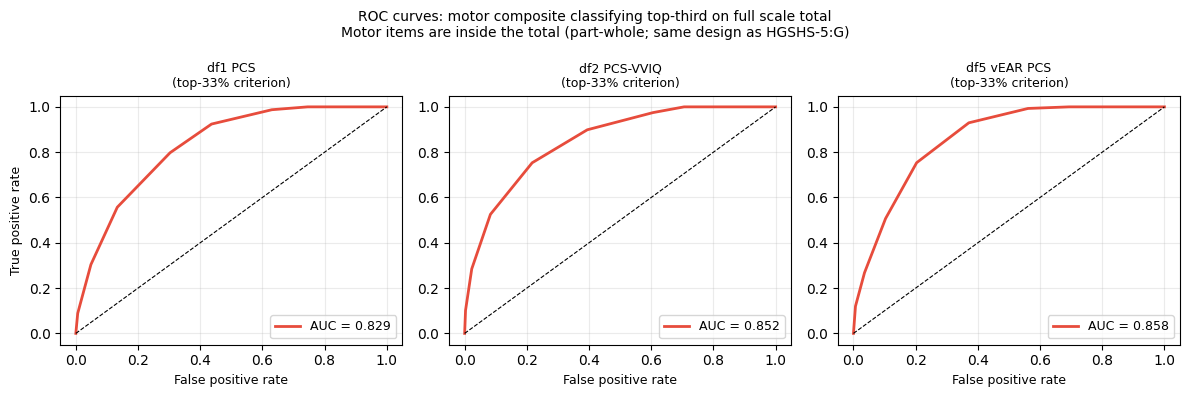

In [11]:
roc_configs = [
    ('df1_pcs', 'df1', 'Subjective_scale_score_first_test', 'df1 PCS'),
    ('df2',     'df2', 'SubjectiveTotal',                   'df2 PCS-VVIQ'),
    ('df5',     'df5', 'PCscore',                           'df5 vEAR PCS'),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (key, mc_key, tc, label) in zip(axes, roc_configs):
    df    = dfs[key]
    mc    = MOTOR_COLS[mc_key]
    motor = df[mc].sum(axis=1).dropna()
    crit  = df.loc[motor.index, tc].dropna()
    idx   = motor.index.intersection(crit.index)
    m = motor.loc[idx].values.astype(float)
    c = crit.loc[idx].values.astype(float)
    true_h = (c > np.quantile(c, 2/3)).astype(int)
    fpr, tpr, _ = roc_curve(true_h, m)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('False positive rate', fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel('True positive rate', fontsize=9)
    ax.set_title(f'{label}\n(top-33% criterion)', fontsize=9)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.25)

fig.suptitle('ROC curves: motor composite classifying top-third on full scale total\n'
             'Motor items are inside the total (part-whole; same design as HGSHS-5:G)',
             fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig4_roc_primary.png', dpi=300, bbox_inches='tight')
plt.show()


**Figure 4.** ROC curves: motor composite classifying the top tertile on the full-scale total.
Motor items are inside the total (part-whole). AUC 0.83–0.86 across three PCS datasets.
SWASH AUC 0.90–0.91; HGSHS:A involuntariness AUC 0.89 (see a04_classification.py for full output).

---
## 6. All 45 two-item combinations

All C(10,2) = 45 two-item combinations are computed per dataset and ranked by r_full.
This tests whether the motor pair is specifically efficient or whether any two
medium-difficulty items would perform similarly.


In [12]:
ITEM_LABELS_SHARED = [
    'Hand lowering', 'Hands together', 'Mosquito', 'Taste',
    'Arm rigidity', 'Arm immobilisation',
    'Music', 'Neg. visual', 'Amnesia', 'Post-hypnotic',
]

def all_pairs_analysis(df, all_items, total_col, motor_cols, dataset_label):
    motor_set  = frozenset(motor_cols)
    item_labels = dict(zip(all_items, ITEM_LABELS_SHARED))
    rows = []
    for c1, c2 in combinations(all_items, 2):
        ps   = df[[c1, c2]].sum(axis=1)
        tot  = df[total_col]
        mask = ps.notna() & tot.notna()
        rf, _ = pearsonr(ps[mask].values, tot[mask].values)

        rest_cols = [c for c in all_items if c not in (c1, c2)]
        rest = df[rest_cols].mean(axis=1)
        msk2 = ps.notna() & rest.notna()
        rr, _ = pearsonr(ps[msk2].values, rest[msk2].values)

        msk3 = df[c1].notna() & df[c2].notna()
        rii, _ = pearsonr(df[c1][msk3].values, df[c2][msk3].values)

        rows.append({
            'dataset':                    dataset_label,
            '_c1':                        c1,
            '_c2':                        c2,
            'pair_label':                 f'{item_labels.get(c1,c1)} + {item_labels.get(c2,c2)}',
            'r_full':                     round(rf, 3),
            'r_rest':                     round(rr, 3),
            'interitem_r':                round(rii, 3),
            'sb':                         round(spearman_brown(rii), 3),
            'is_prespecified_motor_pair': frozenset([c1, c2]) == motor_set,
        })

    result = pd.DataFrame(rows).sort_values('r_full', ascending=False).reset_index(drop=True)
    result['rank_by_r_full'] = result.index + 1
    rest_sorted = result.sort_values('r_rest', ascending=False).reset_index(drop=True)
    rest_sorted['rank_by_r_rest'] = rest_sorted.index + 1
    result = result.merge(rest_sorted[['_c1', '_c2', 'rank_by_r_rest']], on=['_c1', '_c2'])
    result.drop(columns=['_c1', '_c2'], inplace=True)
    return result

pairs_configs = [
    ('df1_pcs',   ITEMS_DF1, 'Subjective_scale_score_first_test', 'df1', 'df1 PCS'),
    ('df1_swash', ITEMS_DF1, 'Subjective_scale_score_first_test', 'df1', 'df1 SWASH'),
    ('df2',       ITEMS_DF2, 'SubjectiveTotal',                   'df2', 'df2 PCS-VVIQ'),
    ('df3',       ITEMS_DF3, 'Subjectivescore',                   'df3', 'df3 SWASH'),
    ('df5',       ITEMS_DF5, 'PCscore',                           'df5', 'df5 vEAR PCS'),
]
pairs_combined = pd.concat([
    all_pairs_analysis(dfs[key], items, tc, MOTOR_COLS[mk], ds_label)
    for key, items, tc, mk, ds_label in pairs_configs
], ignore_index=True)

motor_ranks = pairs_combined[pairs_combined['is_prespecified_motor_pair']][[
    'dataset', 'rank_by_r_full', 'r_full', 'rank_by_r_rest', 'r_rest', 'pair_label'
]].copy()
motor_ranks.columns = ['Dataset', 'Rank r_full /45', 'r_full', 'Rank r_rest /45', 'r_rest', 'Pair']
display(motor_ranks)

print('\nTop pair per dataset:')
for ds in pairs_combined['dataset'].unique():
    top = pairs_combined[pairs_combined['dataset'] == ds].sort_values('r_full', ascending=False).iloc[0]
    print(f'  {ds}: {top["pair_label"]}  r_full={top["r_full"]:.3f}')


,Dataset,Rank r_full /45,r_full,Rank r_rest /45,r_rest,Pair
0,df1 PCS,1,0.783,2,0.565,Arm rigidity + Arm immobilisation
48,df1 SWASH,4,0.849,8,0.694,Arm rigidity + Arm immobilisation
91,df2 PCS-VVIQ,2,0.778,11,0.549,Arm rigidity + Arm immobilisation
147,df3 SWASH,13,0.807,23,0.630,Arm rigidity + Arm immobilisation
180,df5 vEAR PCS,1,0.785,9,0.579,Arm rigidity + Arm immobilisation



Top pair per dataset:
  df1 PCS: Arm rigidity + Arm immobilisation  r_full=0.783
  df1 SWASH: Hand lowering + Arm rigidity  r_full=0.856
  df2 PCS-VVIQ: Hand lowering + Arm immobilisation  r_full=0.778
  df3 SWASH: Taste + Arm rigidity  r_full=0.845
  df5 vEAR PCS: Arm rigidity + Arm immobilisation  r_full=0.785


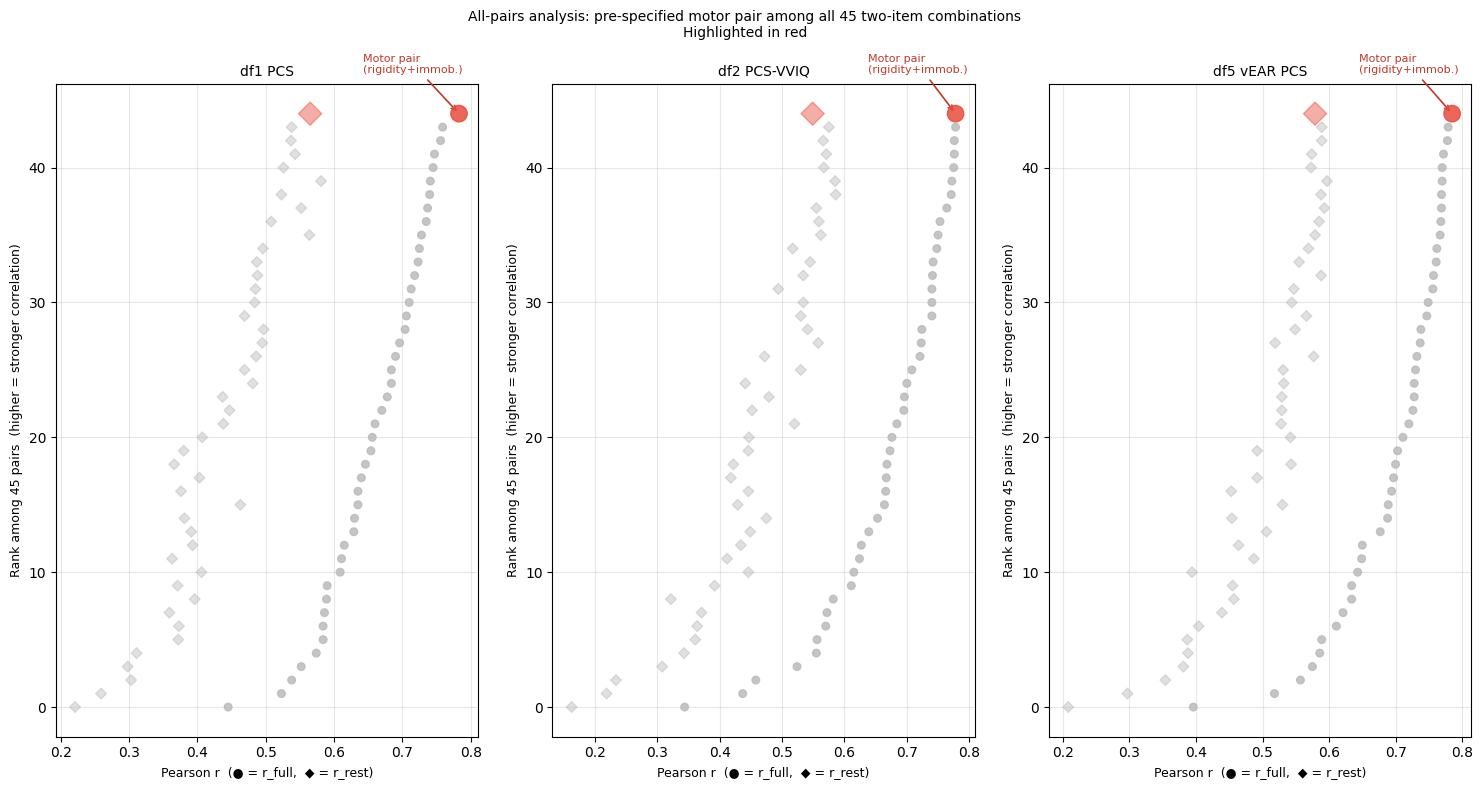

In [13]:
pcs_datasets = ['df1 PCS', 'df2 PCS-VVIQ', 'df5 vEAR PCS']
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

for ax, ds_label in zip(axes, pcs_datasets):
    sub = pairs_combined[pairs_combined['dataset'] == ds_label].copy()
    sub = sub.sort_values('r_full', ascending=True).reset_index(drop=True)
    y   = np.arange(len(sub))

    colours = ['#e74c3c' if row['is_prespecified_motor_pair'] else '#bbb'
               for _, row in sub.iterrows()]
    sizes   = [140 if row['is_prespecified_motor_pair'] else 30
               for _, row in sub.iterrows()]

    ax.scatter(sub['r_full'], y, c=colours, s=sizes, zorder=5, alpha=0.85,  label='r_full')
    ax.scatter(sub['r_rest'], y, c=colours, s=sizes, zorder=5, alpha=0.45,
               marker='D', label='r_rest')

    motor_pos = int(np.where(sub['is_prespecified_motor_pair'].values)[0][0])
    motor_row = sub.iloc[motor_pos]
    ax.annotate('Motor pair\n(rigidity+immob.)',
                xy=(motor_row['r_full'], motor_pos),
                xytext=(motor_row['r_full'] - 0.14, motor_pos + 3),
                fontsize=8, color='#c0392b',
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2))
    ax.set_xlabel('Pearson r  (● = r_full,  ◆ = r_rest)', fontsize=9)
    ax.set_ylabel('Rank among 45 pairs  (higher = stronger correlation)', fontsize=9)
    ax.set_title(ds_label, fontsize=10)
    ax.grid(alpha=0.3)

fig.suptitle('All-pairs analysis: pre-specified motor pair among all 45 two-item combinations\n'
             'Highlighted in red', fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig2_all_pairs_rank.png', dpi=300, bbox_inches='tight')
plt.show()


**Figure 5.** All 45 two-item combinations ranked by r_full (circles) and r_rest (diamonds)
across three PCS datasets. Motor pair highlighted in red.

Motor pair ranks #1 or #2 in all three PCS datasets. In SWASH it ranks lower (#4, #13),
but a motor item appears in the top pair in both SWASH datasets. Perceptual items (music,
negative visual hallucination) never appear in top pairs in any dataset.


---
## 7. Temporal stability

Retest data are available from two sources: the PCS norms retest file (61 PCS, 62 SWASH
participants with full item data at both sessions) and df3 SWASH (66 participants,
total score at T2 only).

All figures reflect stability within the full-scale procedure.
Participants completed all ten items at both sessions.
Standalone retest data for the two-item composite does not exist.


In [14]:
RETEST_MOTOR_T2 = ['ArmRigiditySubjectiveRating_69', 'ArmImmobilisationSubjectiveRating_70']
RETEST_TOTAL_T1 = 'TotalSubjectiveScore'
RETEST_TOTAL_T2 = 'TotalSubjectiveScore_75'

def retest_row(x_t1, x_t2, label_x, label_y, dataset, n_boot=N_BOOT):
    xa = np.asarray(x_t1, dtype=float)
    ya = np.asarray(x_t2, dtype=float)
    mask = np.isfinite(xa) & np.isfinite(ya)
    xa, ya = xa[mask], ya[mask]
    if len(xa) < 10:
        return None
    rp, p = pearsonr(xa, ya)
    rs, _ = spearmanr(xa, ya)
    ci_lo, ci_hi = bootstrap_ci(xa, ya, 'pearson', n_boot=n_boot)
    return {
        'dataset':    dataset,
        'T1_var':     label_x,
        'T2_var':     label_y,
        'n':          len(xa),
        'pearson_r':  round(rp, 3),
        'p_value':    float(p),
        'spearman_r': round(rs, 3),
        'ci_lo':      round(ci_lo, 3),
        'ci_hi':      round(ci_hi, 3),
    }

rt_rows = []
for label, rt_df in [('df1 PCS retest', rt_pcs), ('df1 SWASH retest', rt_swash)]:
    t1_motor = rt_df[MOTOR_COLS['df1']].sum(axis=1)
    t2_motor = rt_df[RETEST_MOTOR_T2].sum(axis=1)
    t1_total = rt_df[RETEST_TOTAL_T1] / 10
    t2_total = rt_df[RETEST_TOTAL_T2] / 10

    # T2 rest score: 8 non-motor items identified by suffix (_65–_74, minus _69/_70)
    rest_items_t1 = [c for c in ITEMS_DF1 if c not in MOTOR_COLS['df1']]
    rest_items_t2 = [c for c in rt_df.columns
                     if c.endswith(('_65','_66','_67','_68','_71','_72','_73','_74'))]
    has_rest_t2 = len(rest_items_t2) >= 8

    for x, y, lx, ly in [
        (t1_motor, t2_motor, 'motor_pair_T1', 'motor_pair_T2'),
        (t1_total, t2_total, 'full_total_T1', 'full_total_T2'),
        (t1_motor, t2_total, 'motor_pair_T1', 'full_total_T2'),
        (t1_total, t2_motor, 'full_total_T1', 'motor_pair_T2'),
    ]:
        r = retest_row(x, y, lx, ly, label)
        if r: rt_rows.append(r)

    if has_rest_t2:
        t1_rest = rt_df[rest_items_t1].mean(axis=1)
        t2_rest = rt_df[rest_items_t2].mean(axis=1)
        for x, y, lx, ly in [
            (t1_rest,  t2_rest,  'rest_score_T1', 'rest_score_T2'),
            (t1_motor, t2_rest,  'motor_pair_T1', 'rest_score_T2'),
        ]:
            r = retest_row(x, y, lx, ly, label)
            if r: rt_rows.append(r)

# df3 SWASH retest (T2 total only)
df3 = dfs['df3']
df3_rt = df3[df3['Subjectivereturnscore'].notna()]
t1_m3 = df3_rt[MOTOR_COLS['df3']].sum(axis=1)
t1_t3 = df3_rt['Subjectivescore']
t2_t3 = df3_rt['Subjectivereturnscore']
for x, y, lx, ly in [
    (t1_m3, t2_t3, 'motor_pair_T1', 'full_total_T2'),
    (t1_t3, t2_t3, 'full_total_T1', 'full_total_T2'),
]:
    r = retest_row(x, y, lx, ly, 'df3 SWASH retest')
    if r: rt_rows.append(r)

rt_out = pd.DataFrame(rt_rows)
display(rt_out[['dataset', 'T1_var', 'T2_var', 'n', 'pearson_r', 'p_value', 'ci_lo', 'ci_hi']])

print('\nPer-item rtt context (PCS norms, n≈61):')
item_rtt = {
    'Hand lowering': 0.323, 'Hands together': 0.318, 'Mosquito': 0.503,
    'Taste': 0.449, 'Arm rigidity*': 0.217, 'Arm immobilisation*': 0.411,
    'Music': 0.645, 'Neg. visual': 0.216, 'Amnesia': 0.337, 'PHS': 0.266,
}
rtt_df = pd.DataFrame(item_rtt.items(), columns=['Item', 'rtt'])
rtt_df['note'] = ''
rtt_df.loc[rtt_df['Item'].str.contains(r'\*'), 'note'] = 'motor item'
rtt_df.loc[rtt_df['Item'] == 'Music',      'note'] = 'floor — sign-flips in SWASH (-0.013)'
rtt_df.loc[rtt_df['Item'] == 'Neg. visual','note'] = 'floor (95%+ at zero)'
print(rtt_df.to_string(index=False))
print(f'\nMean single-item rtt: {rtt_df["rtt"].mean():.3f}')
print('Motor composite embedded rtt ≈ 0.338 PCS / 0.497 SWASH — at single-item level.')
print('Full-scale rtt ≈ 0.523 PCS / 0.560 SWASH — benefit of aggregating 10 items.')
print('Motor pair T1 → rest score T2 (overlap-free): r=0.222 PCS (ns), r=0.460 SWASH (p<.001).')
print('A standalone two-item rtt study does not exist.')

,dataset,T1_var,T2_var,n,pearson_r,p_value,ci_lo,ci_hi
0,df1 PCS retest,motor_pair_T1,motor_pair_T2,61,0.338,0.008,0.051,0.585
1,df1 PCS retest,full_total_T1,full_total_T2,61,0.523,0.000,0.271,0.708
2,df1 PCS retest,motor_pair_T1,full_total_T2,61,0.281,0.028,0.026,0.507
3,df1 PCS retest,full_total_T1,motor_pair_T2,61,0.402,0.001,0.132,0.602
4,df1 PCS retest,rest_score_T1,rest_score_T2,61,0.567,0.000,0.304,0.749
5,df1 PCS retest,motor_pair_T1,rest_score_T2,61,0.222,0.086,-0.031,0.447
6,df1 SWASH retest,motor_pair_T1,motor_pair_T2,62,0.497,0.000,0.242,0.695
7,df1 SWASH retest,full_total_T1,full_total_T2,62,0.560,0.000,0.336,0.729
8,df1 SWASH retest,motor_pair_T1,full_total_T2,62,0.511,0.000,0.317,0.670
9,df1 SWASH retest,full_total_T1,motor_pair_T2,62,0.428,0.001,0.172,0.637



Per-item rtt context (PCS norms, n≈61):
               Item   rtt                                 note
      Hand lowering 0.323                                     
     Hands together 0.318                                     
           Mosquito 0.503                                     
              Taste 0.449                                     
      Arm rigidity* 0.217                           motor item
Arm immobilisation* 0.411                           motor item
              Music 0.645 floor — sign-flips in SWASH (-0.013)
        Neg. visual 0.216                 floor (95%+ at zero)
            Amnesia 0.337                                     
                PHS 0.266                                     

Mean single-item rtt: 0.368
Motor composite embedded rtt ≈ 0.338 PCS / 0.497 SWASH — at single-item level.
Full-scale rtt ≈ 0.523 PCS / 0.560 SWASH — benefit of aggregating 10 items.
Motor pair T1 → rest score T2 (overlap-free): r=0.222 PCS (ns), r=0.460 SWASH (p<.

---
## 8. Robustness

The composite is scored as the simple sum of the two 0–5 ratings.
Alternatives tested: mean (linear rescaling), z-scored sum, PCA (first component),
geometric mean. Pearson r is invariant to linear transformation, so z-scoring and
mean scoring produce identical r values. Non-linear transforms lose information.
Simple sum is used throughout.


In [15]:
rob_configs = [
    ('df1_pcs',   'df1', 'Subjective_scale_score_first_test', 'rest_score', 'df1 PCS'),
    ('df2',       'df2', 'SubjectiveTotal',                   'rest_score', 'df2 PCS-VVIQ'),
    ('df5',       'df5', 'PCscore',                           'rest_score', 'df5 vEAR PCS'),
]
rob_rows = []
for key, mc_key, tc, rc, label in rob_configs:
    df    = dfs[key]
    mc    = MOTOR_COLS[mc_key]
    m_sum  = df[mc].sum(axis=1)
    m_mean = df[mc].mean(axis=1)
    total  = df[tc]
    rest   = df[rc]

    valid = m_sum.notna() & total.notna()
    m_z = stats_zscore(m_sum[valid].values)
    t_z = stats_zscore(total[valid].values)

    r_sum,  _ = pearsonr(m_sum[valid].values,  total[valid].values)
    r_mean, _ = pearsonr(m_mean[valid].values, total[valid].values)
    r_z,    _ = pearsonr(m_z, t_z)
    vr = m_sum.notna() & rest.notna()
    r_rest, _ = pearsonr(m_sum[vr].values, rest[vr].values)

    rob_rows.append({
        'Dataset':             label,
        'N':                   int(valid.sum()),
        'sum vs total (r_full)': round(r_sum,  3),
        'mean vs total':         round(r_mean, 3),
        'z-sum vs z-total':      round(r_z,    3),
        'sum vs rest (r_rest)':  round(r_rest, 3),
    })
display(pd.DataFrame(rob_rows))
print('\nSum = mean = z-score for Pearson r — linear transforms are invariant.')

# df2 scoring bug verification
df2 = dfs['df2']
buggy_cols = ['HandBecomesHeavy', 'MagneticHands', 'Mosquito',
              'SweetSubRating', 'SourSubRating', 'StiffArm', 'HandAndArmHeavy',
              'HappyBirthday', 'ColouredBalls', 'Amnesia',
              'PostHypnoticSub1', 'PostHypnoticSub2']
df2['_BuggyTotal'] = df2[buggy_cols].mean(axis=1)
motor2 = df2[MOTOR_COLS['df2']].sum(axis=1)
r_can, _ = pearsonr(motor2.dropna().values, df2.loc[motor2.dropna().index, 'SubjectiveTotal'].values)
r_bug, _ = pearsonr(motor2.dropna().values, df2.loc[motor2.dropna().index, '_BuggyTotal'].values)
print(f'\ndf2 scoring check:')
print(f'  Canonical 10-item mean:  r={r_can:.3f}  (correct)')
print(f'  Buggy 12-col mean:        r={r_bug:.3f}  (original HypnoScale.ipynb error)')
print(f'  Difference:               {r_can - r_bug:+.3f}')


,Dataset,N,sum vs total (r_full),mean vs total,z-sum vs z-total,sum vs rest (r_rest)
0,df1 PCS,244,0.783,0.783,0.783,0.565
1,df2 PCS-VVIQ,508,0.778,0.778,0.778,0.549
2,df5 vEAR PCS,452,0.785,0.785,0.785,0.579



Sum = mean = z-score for Pearson r — linear transforms are invariant.

df2 scoring check:
  Canonical 10-item mean:  r=0.778  (correct)
  Buggy 12-col mean:        r=0.727  (original HypnoScale.ipynb error)
  Difference:               +0.051


---
## 9. Summary and claim boundaries

| Metric | PCS (3 datasets) | SWASH (2 datasets) | HGSHS:A inv (1 dataset) |
|--------|------------------|--------------------|-------------------------|
| r_full (part-whole) | 0.78–0.79 | 0.81–0.85 | 0.80 |
| R² | 0.61–0.62 | 0.65–0.72 | 0.64 |
| r_rest (overlap-free) | 0.55–0.58 | 0.63–0.69 | 0.66 |
| SB reliability | 0.61–0.63 | 0.75–0.79 | 0.70 |
| kappa_w (full total) | 0.50–0.55 | 0.65–0.66 | 0.65 |
| kappa_w (rest score) | 0.29–0.34 | 0.45–0.46 | 0.52 |
| External r retained (vEAR) | ~80% (r-ratio) | — | — |
| Motor pair rank / 45 | #1–2 | #4, #13 | n/a (12-item scale) |

**What the data support:**
- The motor pair is a promising embedded proxy for broad PCS/SWASH/HGSHS:A response tendency
  in unselected samples.
- It tracks full PCS totals at r=0.78–0.79 (overlap disclosed; motor items inside total).
- It retains 71–80% of the full scale's correlation with external criteria where those
  correlations are nonzero (vEAR, anomalous experiences).
- As an ordinal triage tool: moderate classification agreement against the full total
  (kappa 0.50–0.55 PCS; 0.65 SWASH/HGSHS:A inv), fair-to-moderate against the
  overlap-free rest score (0.29–0.34 PCS; 0.45–0.52 SWASH/HGSHS:A inv).
- Motor items appear in or near the top pair in every PCS dataset.
- SWASH and HGSHS:A involuntariness (both hypnotic contexts) show substantially higher
  coupling than PCS (non-hypnotic) at every metric — the structure replicates,
  the magnitude does not.

**What the data do not support:**
- A validated standalone screener (all administrations embedded in full scale).
- Longitudinal tracking (embedded rtt≈0.338; standalone rtt unknown).
- Full perceptual-cognitive construct coverage.
- Equal performance across hypnotic vs non-hypnotic contexts.

**Limitations:**
| Limitation | Details |
|-----------|---------|
| Embedded administration | Motor pair isolated post-hoc; no standalone retest exists |
| Part-whole overlap | r_full inflated because motor items are inside the total |
| Single age group | All datasets are university students; effects may not generalise |
| All pre-2023 data | Sanger & Pietras (2023) rating-procedure change not represented |
| External criteria sparse | Only df5 has video-rated criterion; anomalous/flow/DES are self-report |

---
## References

Acunzo & Terhune (2021). Standardized measures of hypnotic suggestibility. *Psychological Assessment.*
Eisinga, te Grotenhuis & Pelzer (2013). The reliability of a two-item scale. *International Journal of Public Health.*
Girard & Christensen (2008). Correlated errors in short-form/full-scale comparisons. *Psychological Assessment.*
Lush, Moga, McLatchie & Dienes (2018). SWASH. *Neuroscience of Consciousness.*
Lush, Scott, Seth & Dienes (2021). PCS. *Collabra: Psychology.*
Piccione, Hilgard & Zimbardo (1989). Stability of hypnotizability. *Int. J. Clinical & Experimental Hypnosis.*
Reshetnikov & Terhune (2022). [df4 — verify author order before submission.]
Riegel et al. (2021). HGSHS-5:G five-item short form. *Frontiers in Psychology.*
Sadler & Woody (2004). Item factor analysis of HGSHS:A. *Psychological Assessment.*
Shor & Orne (1962, 1963). Harvard Group Scale of Hypnotic Susceptibility.
Zech et al. (2024). HGSHS-5:G follow-up validation. [21 studies, N=2,529.]
